In [119]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import time

# PARAMETRES DU PLAN D'EXPERIENCE
N_VALUES: list[int] = [10, 12, 15, 17, 20, 22, 25, 30]
NB_SEEDS: int = 25
NB_ITERATIONS: int = 300

# PARAMETRES DE LA GENERATION DES INSTANCES
FUEL_PRICE_PER_KM: float = 0.15
FORBIDDEN_VERTICES_RATIO: float = 0.05
PRECEDENCE_NODES_RATIO: float = 0.15
TOLL_RATIO: float = 0.2
TOLL_MIN_COST: int = 5
TOLL_MAX_COST: int = 30

# PARAMETRES GENERAUX
PENALTY_COST: int = 1_000_000

# Recherche opérationnelle: résolution d'un problème de tournée de véhicules
Membres du groupe: Timothé FARDELLA, Léo MARTIN, Antoine POUZOULET, Louis LE ROUX, Clément OMNÈS

## 1.0. Introduction

L'ADEME confie à notre structure CesiCDP l'étude et le développement de nouvelles solutions de mobilité multimodale intelligente afin de répondre aux enjeux actuels de réduction des émissions de gaz à effet de serre. Le projet vise à modéliser et optimiser des tournées de livraison sur un réseau routier, tout en minimisant la durée totale des trajets et en assurant une gestion optimisée des ressources. Pour ce faire, dans ce livrable nous établirons la modélisation formelle du problème ainsi que son analyse de complexité. Pour la bonne compréhension des principes mathématiques et de nos modélisations, nous avons choisi de réaliser un contexte qui sera utilisé comme exemple tout au long de ce document. 


### 1.1. Contexte
Le contexte choisi est une boucherie confrontée à un défi logistique lors des fêtes de fin d'année. En effet, pour noël la boucherie à subit un grand nombre de commande à livrer en peu de temps et demande alors à son prestataire de livraison (l’ADEME) de trouver une solution pour livrer les commandes efficacement.

Les villes à livrer sont :
- Paris (Point de départ et d'arrivée - Dépôt)
- Rennes
- Rouen
- Bordeaux
- Toulouse
- Lyon

### 1.2. Objectifs d'optimisation

L'objectif est de minimiser le coût total d'une tournée de livraison, c'est-à-dire trouver le chemin le plus court et le moins coûteux permettant à un véhicule de visiter un ensesmble de villes et de revenir à son point de départ. En réduisant les distances parcourues et en évitant les routes les plus coûteuses, on limite directement la consommation de carburant, les émissions polluantes et le temps de trajet. Dans ce contexte, le gain de temps permettra de livrer les commandes à temps pour le repas de noël et à long terme de diminuer les coûts et les émissions CO2 de livraison.

---

## 2.0. Représentation mathématique

### 2.1. Définition des variables

Soit:
- $G= \{V;E\}$ un graphe comportant un ensemble de sommets et d'arêtes.
- $V= \{v_0, v_1, ..., v_{n-1}\}$ un ensemble de sommets.
- $E= \{ \{u,v\}\ \mid u;v \in V, u \neq v\}$ un ensemble contenant des arêtes non orientées, où chaque élément est une paire de sommets distincts $u$ et $v$ appartenant à $V$.
- $P(u,v) = P_{péage} + (e \times P_{distance})$ le poids associé à l'arête entre $u$ et $v$ et $e$ le prix de l'essence par kilomètre.
- $D$ un ensemble de contraintes de précédances sachant que D ⊆ V×V.
- $x_{u,v} \in \{0, 1\}$ est une variable de décision valant $1$ si l'arête $(u,v)$ est empruntée dans la tournée, $0$ sinon.
- $\forall (u,v) \in D, t_u < t_v$ avec $t_u$ le rang de passage du sommet $u$ et $t_v$ le rang de passage du sommet $v$.

</br>

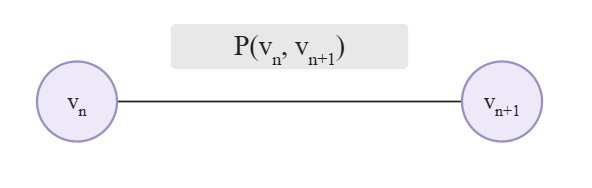

**Ce graphe illustre la modélisation de notre réseau de transport pour le projet CesiCDP. La structure de ce Problème est celle du Voyageur de Commerce (TSP).**

- **Les sommets** : Chaque nœud du graphe correspond à l'une des six villes clés du réseau de distribution. Par exemple, le sommet $v_n$ peut représenter le centre de distribution principal à Paris (point de départ de nos produits), et le sommet $v_{n+1}$ peut désigner Rouen ou Rennes, la prochaine étape où le prestataire logistique doit livrer une commande. 
- **L'arête unique** : Le trait qui relie les deux sommets modélise le réseau routier existant (autoroutes, routes nationales) qu'emprunte le véhicule de l'ADEME pour se rendre de la ville $v_n$ à la ville $v_{n+1}$. Dans notre TSP, le graphe est complet, ce qui signifie qu'il existe une arête entre chaque paire de villes.
- **Le poids ($P(v_n, v_{n+1})$)** : Cette étiquette représente le critère d'optimisation central de notre problème. Elle quantifie l'effort nécessaire pour parcourir cette arête. Dans ce contexte précis, ce poids traduit la distance totale ou le temps de trajet entre deux villes, des facteurs directement corrélés à la consommation énergétique et à l'empreinte carbone.
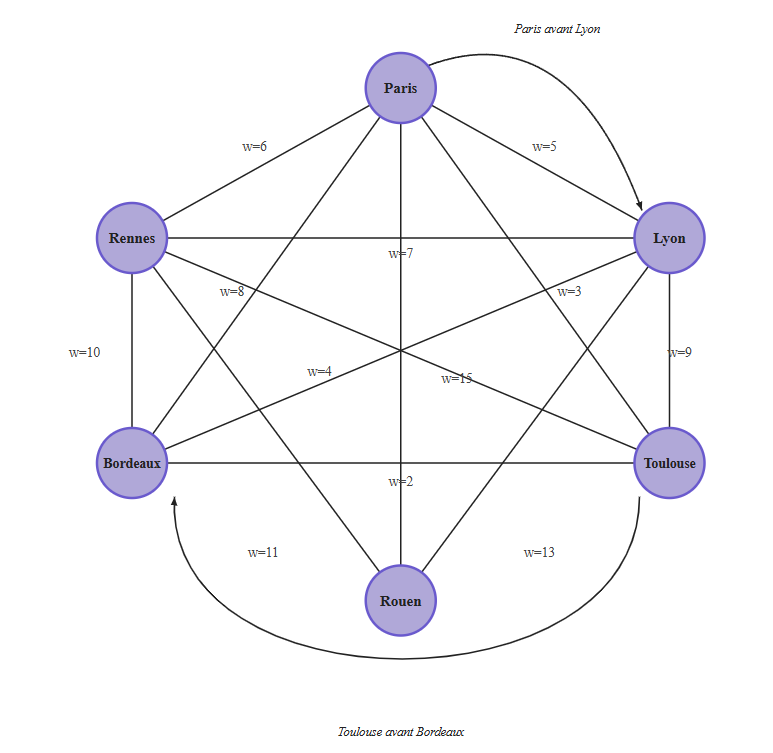
- Le graphe représente une instance du problème TSP-PC-ER appliqué à un réseau de livraison pour une boucherie. Il s'agit d'un graphe complet comportant 6 sommets (villes) et 15 arêtes pondérées.
- **Les sommets représentent les villes à livrer :** $V=\{Rennes,Rouen,Bordeaux,Toulouse,Paris,Lyon\}$
- Les arêtes sont pondérées par la fonction de $\text{coût péage} + \text{le prix de l'essence} \times \text{la distance entre deux villes}$
- Les valeurs $−1$ matérialisent les routes interdites au sens de la contrainte *3.2.1* : ces liaisons ne peuvent pas être empruntées lors de la tournée. Dans notre contexte cela symboliserai une route en travaux qui ne pourra donc pas être empruntée. 
- Les arêtes valides portent des poids entiers positifs représentant le coût de chaque trajet.

---

## 3.0. Définition des fonctions

Dans cette section, nous traduisons le besoin opérationnel de la boucherie en fonctions mathématiques. La démarche suivie est la suivante : identifier la décision logistique à prendre (choisir ou non une arête), associer un coût réel à chaque liaison, puis formaliser les contraintes du terrain (routes interdites et ordre de passage).

Ainsi, les fonctions définies ci-dessous ne sont pas abstraites : elles correspondent directement au contexte de livraison avant Noël, où l'on cherche à minimiser les coûts tout en respectant les contraintes de circulation et d'organisation.

### 3.1. Définition de la fonction objectif

$$\text{min Z} = \sum_{u=0}^{n} \sum_{v=0}^{n} P(u,v) ⋅ x_{(u,v)}$$

L'objectif du problème est de minimiser le coût total du trajet. Le coût d'un trajet dépend de deux éléments déjà définis dans la section 1.0 :

- La variable binaire $x_{u,v} \in \{0,1\}$, qui indique si l'arête entre $u$ et $v$ est utilisée dans la tournée ($1$ = empruntée, $0$ = ignorée).
- Le poids $P(u,v)=P_{péage} + (e \times P_{distance})$, qui représente le coût réel de chaque route, en intégrant les péages et la consommation de carburant.

La somme double sur tous les couples $(u,v)$ agrège le coût total de la tournée, en ne comptant que les arêtes sélectionnées. Les arêtes non retenues (où $x_{u,v}=0$) ne contribuent pas à la somme.

Dans le contexte appliqué, cette fonction objectif correspond à la recherche de la tournée la moins coûteuse pour livrer toutes les villes puis revenir au dépôt (Paris). En minimisant cette quantité, on réduit à la fois les dépenses logistiques, la consommation de carburant et l'impact environnemental.

</br>

### 3.2. Définition des fonctions contraintes

Les contraintes permettent d'intégrer les réalités du problème dans le modèle. Elles évitent de produire une solution mathématiquement optimale mais logistiquement irréaliste.

#### 3.2.1. Contrainte de coût et d'arêtes interdites

Une arête $(u,v)$ est considérée comme interdite lorsque son poids vaut $-1$. On impose alors :

$$x_{u,v} = 0 \ \forall(u,v) \in E \text{ tel que } P(u,v) = -1$$

Cette contrainte traduit le fait qu'une liaison bloquée (ou non autorisée) ne peut jamais être empruntée pendant la tournée.

#### 3.2.2. Contrainte de précédances

Pour toute paire $(u,v) \in D$, la ville $u$ doit être visitée avant la ville $v$:

$$t_u < t_v ∀(u,v) \in D$$

Cette contrainte modélise un ordre de livraison imposé (priorité de certains clients, organisation de tournée, contraintes métier). Elle garantit que la solution retenue reste cohérente avec les exigences opérationnelles du contexte.


## 4.0. Calcul de complexité

### 4.1. Identification du problème

Notre problème est une extension du **problème du Voyageur de Commerce** (TSP — *Travelling Salesman Problem*), noté **TSP-PC-ER**, car il intègre deux contraintes supplémentaires par rapport au TSP classique :

- **PC** (*Precedence Constraints*) — l'ensemble $D \subseteq V \times V$ impose un ordre de visite entre certaines villes : $\forall (u,v) \in D,\ t_u < t_v$
- **ER** (*Edge Restrictions*) — certaines arêtes sont bloquées ($P_n(u,v) = -1$) ou affectées d'un surcoût

La méthode utilisée pour déterminer la complexité d'un problème est la **réduction polynomiale** : on montre qu'un problème déjà connu comme difficile se ramène au nôtre. On s'appuie sur la chaîne suivante :

$$\underbrace{\text{Ham-Cycle}}_{\text{NP-Complet}} \leq_p \underbrace{\text{TSP}}_{\text{NP-Difficile (Karp, 1972)}} \leq_p \underbrace{\text{TSP-PC-ER}}_{\text{notre problème}}$$

La réduction Ham-Cycle $\leq_p$ TSP est un résultat établi de la littérature (Karp, 1972), cité ici comme acquis. Nous démontrons la seconde réduction : **TSP $\leq_p$ TSP-PC-ER**.

### 4.2. TSP-PC-ER $\in$ NP

Un certificat est une liste ordonnée des sommets du circuit. On vérifie en $O(n)$ que :

- chaque sommet apparaît exactement une fois,
- aucune arête empruntée n'est bloquée ($P(u,v) \neq -1$),
- la somme des poids des arêtes consécutives est au plus $k$,
- toutes les contraintes de précédence de $D$ sont respectées.

La vérification est polynomiale, donc :

$$\text{TSP-PC-ER} \in NP$$

### 4.3. Réduction TSP $\leq_p$ TSP-PC-ER


Le TSP classique est un **cas particulier** de notre problème TSP-PC-ER.  
La réduction se construit ainsi : étant donné une instance TSP quelconque — un graphe $G = (V, E, w)$ — on construit une instance TSP-PC-ER en posant :

$$D = \emptyset \qquad \text{et} \qquad P(u,v) = w(\{u,v\}) \quad \forall \{u,v\} \in E$$

- $D = \emptyset$ signifie qu'on ne définit **aucune contrainte de précédence**
- $P(u,v) = w(\{u,v\})$ signifie qu'on recopie les poids tels quels, **sans route bloquée ni surcoût**

Cette transformation ne modifie rien — elle recopie l'instance en $O(1)$, ce qui est triviallement polynomial.

On obtient alors exactement l'instance TSP de départ. On en déduit :

$$\text{TSP} \leq_p \text{TSP-PC-ER}$$

Si on savait résoudre TSP-PC-ER efficacement, on saurait aussi résoudre TSP — ce qui est impossible puisque TSP est NP-Difficile. Les schémas ci-dessous illustrent cette réduction : à gauche le TSP pur (tous les poids à 1, aucune contrainte), à droite le TSP-PC-ER avec ses contraintes. En posant $D = \emptyset$ et $P(u,v) = 1$ partout, on passe du second au premier.

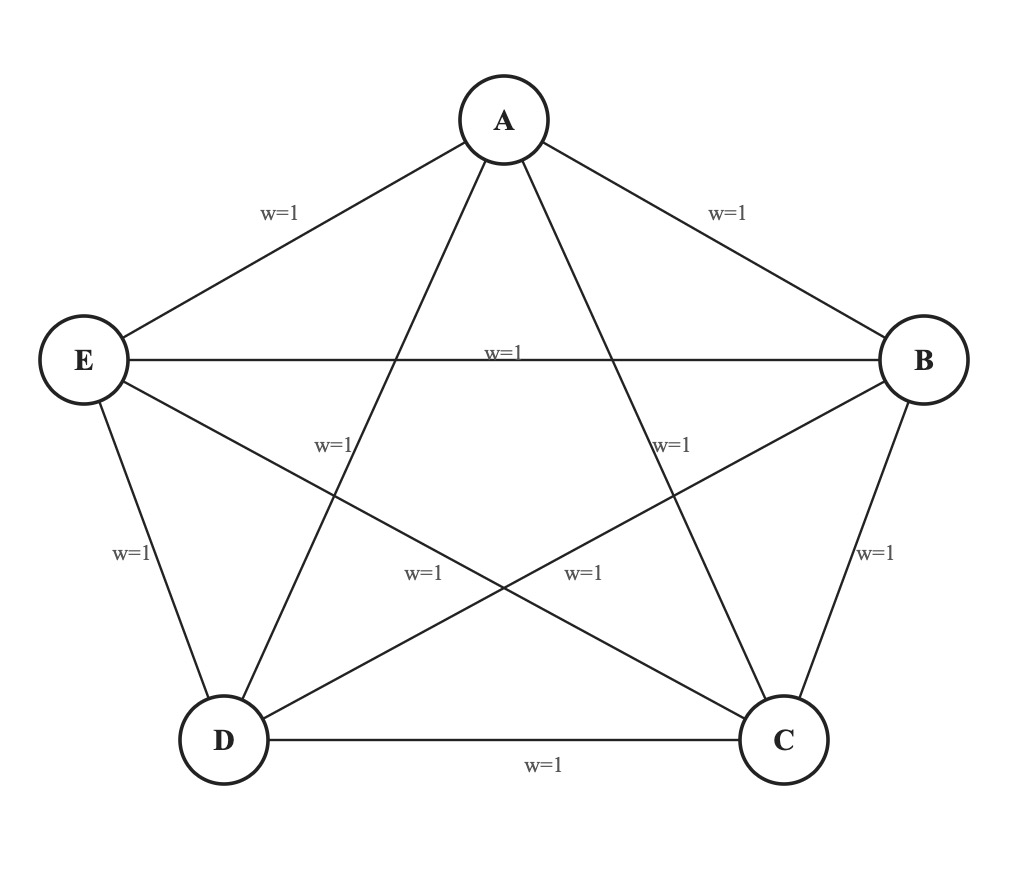
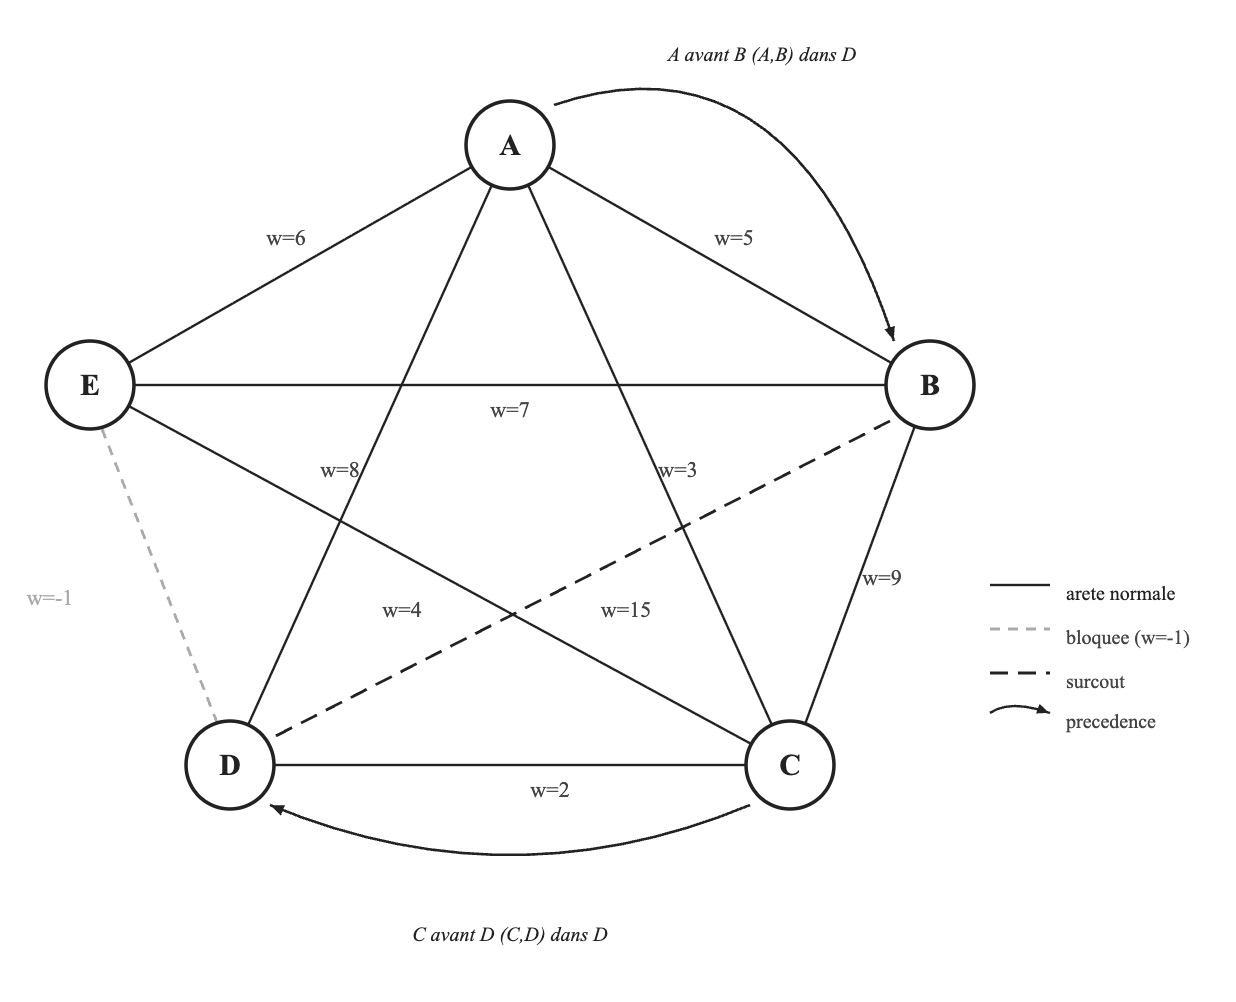

### 4.4. Complexité liée aux contraintes

On pourrait penser que l'ajout de contraintes réduit la difficulté du problème — en interdisant des arêtes ou en imposant un ordre de visite, on élimine des tournées invalides. C'est vrai en pratique, mais insuffisant pour changer la classe de complexité.

Sans aucune contrainte, le nombre de tournées distinctes à explorer pour $n$ sommets est :

$$\frac{(n-1)!}{2}$$

Ce résultat s'explique en deux étapes : on fixe $v_0$ comme point de départ, ce qui ramène le nombre de permutations à $(n-1)!$, puis on divise par $2$ car parcourir un cycle dans un sens ou dans l'autre revient au même sur un graphe non orienté.

Nos contraintes réduisent ce nombre, mais il reste **exponentiel en $n$** — diviser par une constante ne change pas l'ordre de grandeur asymptotique.

| $n$ (sommets) | $(n-1)!/2$ | Ordre de grandeur |
|:---:|---:|:---:|
| 5 | 12 | $10^1$ |
| 10 | 181 440 | $10^5$ |
| 15 | 43 589 145 600 | $10^{10}$ |
| 20 | 60 822 550 204 416 000 | $10^{16}$ |

Il n'existe donc pas d'algorithme polynomial connu permettant de résoudre TSP-PC-ER de manière exacte pour de grandes instances. Cela justifie le recours à des **heuristiques** dans les phases suivantes du projet.

---

## 5.0. Choix et description des algorithmes

TODO: A REDIGER

Algos: 
- Colonie de fourmis: 
- Génétique:
- Hill Climbing Multi Start:
- Plus proche voisin:
- Recuit simulé:
- Recherche tabou:

---

## 6.0. Implémentation

### 6.1. Générateur de graphe
TODO: A REDIGER

In [120]:
def compute_toll_cost(a: int, b: int) -> int:
    """Compute a random toll cost between a and b."""
    return int(np.random.randint(a, b))

def compute_weight(distance: float) -> float:
    """Compute the weight of an edge based on distance, fuel price, and a random chance of having a toll."""
    has_toll: bool = np.random.rand() < TOLL_RATIO
    if has_toll:
        return compute_toll_cost(TOLL_MIN_COST, TOLL_MAX_COST) + (distance * FUEL_PRICE_PER_KM)
    return distance * FUEL_PRICE_PER_KM

def is_forbidden_vertex() -> bool:
    """Randomly determine if an edge is forbidden based on the FORBIDDEN_VERTICES_RATIO."""
    return np.random.rand() < FORBIDDEN_VERTICES_RATIO

def is_precedence_constraint() -> bool:
    """Randomly determine if a node has a precedence constraint."""
    return np.random.rand() < PRECEDENCE_NODES_RATIO

def get_random_node_preference(graph_size: int, precedences: dict[int, int], current_node: int) -> int:
    """Get a random node that is not already a key in the precedences dict, and does not have current_node as a value in the precedences dict (to avoid cycles). Fallback to -1 if no valid node found after 1000 attempts."""
    for _ in range(100):
        node: int = int(np.random.randint(0, graph_size))
        # reject if already a key, or if inverse exists: {node: current_node} would conflict with {current_node: node}
        if node not in precedences and node != current_node:
            return node

    return -1 # fallback if no valid node found after 1000 attempts

def generate_graph(n: int) -> nx.Graph:
    """Generate a complete graph with n nodes, where each edge has a weight based on distance and fuel price, and some edges may be forbidden. Additionally, some nodes may have precedence constraints."""
    graph = nx.complete_graph(n)
    precedences: dict[int, int] = {} # first key is the node, second key is the precedence node
    for node in graph.nodes():
        if is_precedence_constraint():
            precedence_node: int = get_random_node_preference(n, precedences, node)
            if precedence_node != -1:
                precedences[node] = precedence_node
                graph.nodes[node]["precedence"] = precedence_node
            else:
                graph.nodes[node]["precedence"] = None
        else:
            graph.nodes[node]["precedence"] = None

    for u, v in graph.edges():
        is_forbidden: bool = is_forbidden_vertex()
        distance: int = int(np.random.randint(1, 100))
        weight: float = -1 if is_forbidden else compute_weight(distance)

        graph.edges[u, v]["weight"] = weight
    return graph

def display_graph(graph: nx.Graph) -> None:
    """Display the graph using Matplotlib, with different colors for normal edges, forbidden edges, and precedence constraints."""
    precedences_edges: list[tuple[int, int]] = [(u, precedence) for u, precedence in graph.nodes(data='precedence') if precedence is not None]
    normal: list[tuple[int, int]] = []
    forbidden: list[tuple[int, int]] = []

    for u, v in graph.edges():
        forbidden.append((u, v)) if (graph.edges[u, v]["weight"] == -1) else normal.append((u, v))

    edge_labels: dict[tuple[int, int], str] = {
        (u, v): f"{graph.edges[u, v]['weight']:.2f}"
        for (u, v) in normal
    }

    plt.figure(figsize=(10, 10))

    pos = nx.circular_layout(graph)
    nx.draw_networkx_nodes(graph, pos, node_size=500)
    nx.draw_networkx_labels(graph, pos)
    nx.draw_networkx_edges(graph, pos, edgelist=normal, edge_color="b", alpha=0.5)
    nx.draw_networkx_edges(graph, pos, edgelist=forbidden, edge_color="r", alpha=0.5, style="dashed", width=1.5)
    nx.draw_networkx_edges(graph, pos, edgelist=precedences_edges, edge_color="g", alpha=1, connectionstyle="arc3,rad=0.3", arrows=True, arrowstyle='->', width=2)
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=7)

    plt.axis("off")

def display_path(graph: nx.Graph, path: list[int]) -> None:
    """Display the graph and overlay a path through the given node sequence."""
    precedences_edges: list[tuple[int, int]] = [(u, precedence) for u, precedence in graph.nodes(data='precedence') if precedence is not None]
    normal: list[tuple[int, int]] = []
    forbidden: list[tuple[int, int]] = []

    for (u, v) in graph.edges():
        forbidden.append((u, v)) if (graph.edges[u, v]["weight"] == -1) else normal.append((u, v))

    path_edges: list[tuple[int, int]] = [
        (path[i], path[i + 1])
        for i in range(len(path) - 1)
        if graph.has_edge(path[i], path[i + 1]) and graph.edges[path[i], path[i + 1]]["weight"] != -1
    ]

    edge_labels: dict[tuple[int, int], str] = {
        (u, v): f"{graph.edges[u, v]['weight']:.2f}" for (u, v) in normal
    }

    plt.figure(figsize=(10, 10))

    pos = nx.circular_layout(graph)
    nx.draw_networkx_nodes(graph, pos, node_size=500)
    nx.draw_networkx_labels(graph, pos)
    nx.draw_networkx_edges(graph, pos, edgelist=normal, edge_color="b", alpha=0.5)
    nx.draw_networkx_edges(graph, pos, edgelist=forbidden, edge_color="r", alpha=0.5, style="dashed", width=1.5)
    nx.draw_networkx_edges(graph, pos, edgelist=precedences_edges, edge_color="g", alpha=1, connectionstyle="arc3,rad=0.3", arrows=True, arrowstyle="->", width=2)
    nx.draw_networkx_edges(graph, pos, edgelist=path_edges, edge_color="magenta", alpha=1, connectionstyle="arc3,rad=0.2", arrows=True, arrowstyle="->", width=2)
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=7)

    plt.axis("off")

### 6.2. Fonctions utilitaires

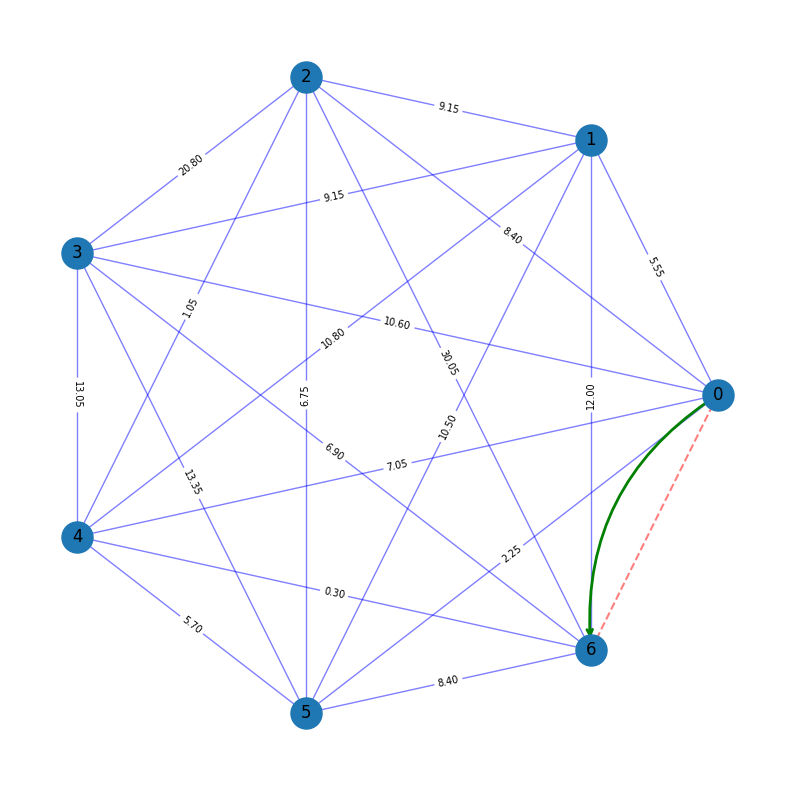

In [121]:
test_graph = generate_graph(7)
display_graph(test_graph)

def print_graph_test(best_tour: list[int], best_cost: float, display_name: str) -> None:
    """Test the validity of a tour and print its cost."""
    if best_tour:
        print(display_name + ": Ordre des sommets dans le meilleur tour :", best_tour)
        print(display_name + ": Coût du meilleur tour :", round(best_cost, 2))
    else:
        print(display_name + ": Aucun tour valide trouvé.")

def node_can_be_visited(graph: nx.Graph, node: int, visited: set[int]) -> bool:
    """Check if a node can be visited based on its precedence constraint."""
    precedence: int | None = graph.nodes[node].get("precedence")
    return precedence is None or precedence in visited


def valid_next_nodes(graph: nx.Graph, current: int, visited: set[int]) -> list[int]:
    """Get a list of valid next nodes that can be visited from the current node, based on the graph's edges, weights, and precedence constraints."""
    return [
        node
        for node in graph.nodes()
        if node not in visited
        and node_can_be_visited(graph, node, visited)
        and graph.edges[current, node]["weight"] != -1
    ]


def calculate_tour_cost_with_penalty(
    graph: nx.Graph,
    tour: list[int],
    penalty_cost: float = PENALTY_COST,
) -> float:
    """Calculate a closed tour cost, penalizing forbidden edges and precedence violations."""
    cost: float = 0.0

    for i in range(len(tour)):
        u: int = tour[i]
        v: int = tour[(i + 1) % len(tour)]
        if graph.has_edge(u, v):
            weight: float = graph.edges[u, v].get("weight", -1)
        else:
            weight = -1

        if weight == -1:
            cost += penalty_cost
        else:
            cost += weight

    for index, node in enumerate(tour):
        precedence: int | None = graph.nodes[node].get("precedence")
        if precedence is not None:
            if precedence not in tour:
                cost += penalty_cost
                continue

            precedence_index: int = tour.index(precedence)
            if precedence_index > index:
                cost += penalty_cost

    return cost


def build_greedy_tour(graph: nx.Graph) -> list[int]:
    """Build an initial tour using a nearest-neighbor heuristic."""
    nodes: list[int] = list(graph.nodes())
    start_candidates: list[int] = [
        n for n in nodes if graph.nodes[n].get("precedence") is None
    ]
    if not start_candidates:
        start_candidates = nodes

    best_tour: list[int] = []
    best_cost: float = float("inf")

    for start in start_candidates:
        tour: list[int] = [start]
        visited: set[int] = {start}

        while len(tour) < len(nodes):
            current: int = tour[-1]
            valid: list[int] = [
                n
                for n in nodes
                if n not in visited
                and node_can_be_visited(graph, n, visited)
                and graph.edges[current, n]["weight"] != -1
            ]
            if not valid:
                break
            nearest: int = min(valid, key=lambda n: graph.edges[current, n]["weight"])
            tour.append(nearest)
            visited.add(nearest)

        if len(tour) != len(nodes):
            continue
        if graph.edges[tour[-1], tour[0]]["weight"] == -1:
            continue

        cost: float = closed_tour_cost(graph, tour)

        if cost < best_cost:
            best_cost = cost
            best_tour = tour

    return best_tour


def closed_tour_cost(graph: nx.Graph, tour: list[int]) -> float:
    """Compute the total cost of a closed tour (last node to first node included)."""
    cost: float = sum(graph.edges[u, v]["weight"] for u, v in zip(tour, tour[1:]))
    cost += graph.edges[tour[-1], tour[0]]["weight"]
    return cost


def is_tour_feasible(graph: nx.Graph, tour: list[int]) -> bool:
    """Check that every edge in a closed tour exists and respects precedences."""
    visited: set[int] = set()
    for idx, node in enumerate(tour):
        if not node_can_be_visited(graph, node, visited):
            return False
        visited.add(node)

        next_node: int = tour[(idx + 1) % len(tour)]
        if not graph.has_edge(node, next_node):
            return False
        if graph.edges[node, next_node]["weight"] == -1:
            return False

    return True

### 6.3. Algorithmes et exemples

#### 6.3.1. Colonie de fourmis

In [122]:
def resolve_by_ant_system(
    graph: nx.Graph,
    n_iterations: int = 200,
    n_ants: int | None = None,
    alpha: float = 1.0,
    beta: float = 5.0,
    evaporation_rate: float = 0.5,
    initial_pheromone: float = 1.0,
) -> tuple[list[int], float]:
    """Resolve the graph using a simple ant colony optimization algorithm."""
    node_count: int = graph.number_of_nodes()
    if node_count == 0:
        return [], 0.0

    if n_ants is None:
        n_ants = node_count

    start_candidates: list[int] = [node for node in graph.nodes() if graph.nodes[node].get("precedence") is None]
    if not start_candidates:
        start_candidates = list(graph.nodes())

    pheromones: np.ndarray = np.full((node_count, node_count), initial_pheromone, dtype=float)
    best_tour: list[int] = []
    best_cost: float = float("inf")

    for _ in range(n_iterations):
        iteration_solutions: list[tuple[list[int], float]] = []

        for _ in range(n_ants):
            start: int = int(np.random.choice(start_candidates))
            tour: list[int] = [start]
            visited: set[int] = {start}

            while len(tour) < node_count:
                current: int = tour[-1]
                neighbors: list[int] = valid_next_nodes(graph, current, visited)
                if not neighbors:
                    break

                scores: list[float] = []
                for neighbor in neighbors:
                    weight: float = graph.edges[current, neighbor]["weight"]
                    score: float = (pheromones[current, neighbor] ** alpha) * ((1.0 / weight) ** beta)
                    scores.append(score)

                scores_array: np.ndarray = np.array(scores, dtype=float)
                if scores_array.sum() <= 0:
                    next_node: int = int(np.random.choice(neighbors))
                else:
                    probabilities: np.ndarray = scores_array / scores_array.sum()
                    next_node: int = int(np.random.choice(neighbors, p=probabilities))

                tour.append(next_node)
                visited.add(next_node)

            if len(tour) != node_count:
                continue

            total_cost: float = 0.0
            feasible: bool = True
            for u, v in zip(tour, tour[1:]):
                weight: float = graph.edges[u, v]["weight"]
                if weight == -1:
                    feasible = False
                    break
                total_cost += weight

            if not feasible:
                continue

            return_weight: float = graph.edges[tour[-1], tour[0]]["weight"]
            if return_weight == -1:
                continue

            total_cost += return_weight
            closed_tour: list[int] = tour + [tour[0]]

            if total_cost < best_cost:
                best_cost = total_cost
                best_tour = closed_tour

            iteration_solutions.append((tour, total_cost))

        pheromones *= (1.0 - evaporation_rate)
        for tour, cost in iteration_solutions:
            deposit: float = 1.0 / cost
            for u, v in zip(tour, tour[1:]):
                pheromones[u, v] += deposit
                pheromones[v, u] += deposit
            pheromones[tour[-1], tour[0]] += deposit
            pheromones[tour[0], tour[-1]] += deposit

    if not best_tour:
        return [], float("inf")

    return best_tour, best_cost

##### 6.3.1.1. Cas de test

In [123]:
best_tour, best_cost = resolve_by_ant_system(test_graph, n_iterations=100, n_ants=10)
print_graph_test(best_tour, best_cost, "Colonie de Fourmis")

Colonie de Fourmis: Ordre des sommets dans le meilleur tour : [6, 4, 2, 5, 0, 1, 3, 6]
Colonie de Fourmis: Coût du meilleur tour : 31.95


#### 6.3.2. Génétique

In [124]:
def _generate_random_individual(nodes: list[int]) -> list[int]:
    """Generate a random valid individual for the population."""
    individual: list[int] = nodes.copy()
    random.shuffle(individual)
    return individual


def _ordered_crossover(parent1: list[int], parent2: list[int]) -> list[int]:
    """Perform ordered crossover (OX) between two parents."""
    size: int = len(parent1)
    start: int
    end: int
    start, end = sorted(random.sample(range(size), 2))
    child: list[int] = [-1] * size
    child[start : end + 1] = parent1[start : end + 1]

    pointer: int = end + 1
    for gene in parent2[end + 1 :] + parent2[: end + 1]:
        if gene not in child:
            if pointer >= size:
                pointer = 0
            child[pointer] = gene
            pointer += 1

    return child


def _swap_mutation(individual: list[int], mutation_rate: float) -> list[int]:
    """Perform swap mutation on an individual."""
    if random.random() < mutation_rate:
        i: int
        j: int
        i, j = random.sample(range(len(individual)), 2)
        individual[i], individual[j] = individual[j], individual[i]
    return individual


def _tournament_selection(
    population: list[list[int]], costs: list[float], tournament_size: int
) -> list[int]:
    """Select an individual using tournament selection."""
    participants: list[tuple[list[int], float]] = random.sample(list(zip(population, costs)), tournament_size)
    participants.sort(key=lambda item: item[1])
    return participants[0][0].copy()


def resolve_by_genetic(
    graph: nx.Graph,
    population_size: int = 50,
    generations: int = 200,
    crossover_rate: float = 0.8,
    mutation_rate: float = 0.2,
    tournament_size: int = 3,
    elite_size: int = 2,
) -> tuple[list[int], float]:
    """Resolve the graph using a simple genetic algorithm."""
    nodes: list[int] = list(graph.nodes())
    node_count: int = len(nodes)

    if node_count == 0:
        return [], 0.0

    population: list[list[int]] = [_generate_random_individual(nodes) for _ in range(population_size)]
    best_tour: list[int] = []
    best_cost: float = float("inf")

    for _ in range(generations):
        costs: list[float] = [
            calculate_tour_cost_with_penalty(graph, individual)
            for individual in population
        ]

        for individual, cost in zip(population, costs):
            if cost < best_cost:
                best_cost = cost
                best_tour = individual.copy()

        new_population: list[list[int]] = []
        sorted_population: list[list[int]] = [
            individual
            for _, individual in sorted(
                zip(costs, population), key=lambda item: item[0]
            )
        ]
        new_population.extend(sorted_population[:elite_size])

        while len(new_population) < population_size:
            parent1: list[int] = _tournament_selection(population, costs, tournament_size)
            parent2: list[int] = _tournament_selection(population, costs, tournament_size)

            if random.random() < crossover_rate:
                child: list[int] = _ordered_crossover(parent1, parent2)
            else:
                child = parent1.copy()

            child = _swap_mutation(child, mutation_rate)
            new_population.append(child)

        population = new_population

    if not best_tour:
        return [], float("inf")

    return best_tour + [best_tour[0]], best_cost

##### 6.3.2.1. Cas de test

In [125]:
best_tour, best_cost = resolve_by_genetic(test_graph, generations=100, population_size=50)
print_graph_test(best_tour, best_cost, "Algorithme Génétique")

Algorithme Génétique: Ordre des sommets dans le meilleur tour : [4, 6, 3, 1, 0, 5, 2, 4]
Algorithme Génétique: Coût du meilleur tour : 31.95


#### 6.3.3. Hill Climbing Multi Start

In [126]:
def _generate_random_tour(nodes: list) -> list:
    """Generates an initial random solution (permutation of nodes)."""
    tour: list = list(nodes)
    depot: int = tour[0]
    rest_of_tour: list = tour[1:]
    random.shuffle(rest_of_tour)
    return [depot] + rest_of_tour


def _get_neighbors(tour: list) -> list:
    """Generates the neighborhood using a simple 2-node swap."""
    neighbors: list = []
    for i in range(1, len(tour) - 1):
        for j in range(i + 1, len(tour)):
            neighbor: list = tour.copy()
            neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
            neighbors.append(neighbor)
    return neighbors


def resolve_by_hill_climbing(graph: nx.Graph, initial_tour: list) -> tuple:
    """Executes a single hill climbing pass."""
    current_tour: list = initial_tour
    current_cost: float = calculate_tour_cost_with_penalty(graph, current_tour)

    while True:
        neighbors: list = _get_neighbors(current_tour)
        best_neighbor: list | None = None
        best_neighbor_cost: float = current_cost

        for neighbor in neighbors:
            cost: float = calculate_tour_cost_with_penalty(graph, neighbor)
            if cost < best_neighbor_cost:
                best_neighbor = neighbor
                best_neighbor_cost = cost

        if best_neighbor is not None:
            current_tour = best_neighbor
            current_cost = best_neighbor_cost
        else:
            break

    return current_tour, current_cost


def resolve_by_ms_hill_climbing(graph: nx.Graph, iterations: int = 50) -> tuple:
    """Runs the Hill Climbing algorithm multiple times from different starting points."""
    nodes: list = list(graph.nodes())
    global_best_tour: list | None = None
    global_best_cost: float = float("inf")

    for _ in range(iterations):
        initial_tour: list = _generate_random_tour(nodes)

        final_tour: list
        final_cost: float
        final_tour, final_cost = resolve_by_hill_climbing(graph, initial_tour)

        if final_cost < global_best_cost:
            global_best_cost = final_cost
            global_best_tour = final_tour

    if global_best_tour is None or global_best_cost >= PENALTY_COST:
        print("No valid tour is possible with the current constraints.")
        return [], float("inf")

    return global_best_tour, global_best_cost

##### 6.3.3.1. Cas de test

In [127]:
best_tour, best_cost = resolve_by_ms_hill_climbing(test_graph, iterations=100)
print_graph_test(best_tour, best_cost, "Hill Climbing Multi-start")

No valid tour is possible with the current constraints.
Hill Climbing Multi-start: Aucun tour valide trouvé.


#### 6.3.4. Plus Proche Voisin

In [128]:
def _nearest_neighbor_tour(graph: nx.Graph, start: int) -> tuple[list[int], float]:
    """
    Build a tour using the nearest neighbour heuristic from a given start node.
    At each step the closest unvisited reachable node (lowest edge weight) is chosen.
    If no valid neighbour exists the algorithm falls back to any unvisited node,
    accumulating a penalty so the result remains comparable with other solvers.
    Returns the closed tour and its total cost.
    """
    node_count: int = graph.number_of_nodes()
    tour: list[int] = [start]
    visited: set[int] = {start}

    while len(tour) < node_count:
        current: int = tour[-1]
        candidates: list[int] = valid_next_nodes(graph, current, visited)

        if candidates:
            # Pick the nearest cheapest valid neighbour
            next_node = min(candidates, key=lambda n: graph.edges[current, n]["weight"])
        else:
            # Fallback: any unvisited node that satisfies precedence (ignoring forbidden edges)
            fallback: list[int] = [
                n
                for n in graph.nodes()
                if n not in visited and node_can_be_visited(graph, n, visited)
            ]
            if not fallback:
                # Last resort: any unvisited node
                fallback = [n for n in graph.nodes() if n not in visited]
            if not fallback:
                break
            next_node = fallback[0]

        tour.append(next_node)
        visited.add(next_node)

    cost: float = calculate_tour_cost_with_penalty(graph, tour)
    return tour + [tour[0]], cost


def resolve_by_nearest_neighbor(
    graph: nx.Graph,
    multi_start: bool = True,
) -> tuple[list[int], float]:
    """
    Resolve the TSP using the nearest neighbour heuristic.

    When *multi_start* is True (default) the algorithm is run once from every
    node and the best closed tour is returned, which greatly reduces sensitivity
    to the arbitrary choice of starting point.
    When *multi_start* is False a single run is performed from a random node
    that has no precedence constraint.
    """
    node_count: int = graph.number_of_nodes()
    if node_count == 0:
        return [], 0.0

    if multi_start:
        starts: list[int] = list(graph.nodes())
    else:
        free_starts: list[int] = [
            n for n in graph.nodes() if graph.nodes[n].get("precedence") is None
        ]
        starts: list[int] = [
            int(np.random.choice(free_starts if free_starts else list(graph.nodes())))
        ]

    best_tour: list[int] = []
    best_cost: float = float("inf")

    for start in starts:
        tour: list[int]
        cost: float
        tour, cost = _nearest_neighbor_tour(graph, start)
        if cost < best_cost:
            best_cost = cost
            best_tour = tour

    return best_tour, best_cost


##### 6.3.4.1. Cas de test

In [129]:
best_tour, best_cost = resolve_by_nearest_neighbor(test_graph, multi_start=True)
print_graph_test(best_tour, best_cost, "Plus Proche Voisin Multi-start")

Plus Proche Voisin Multi-start: Ordre des sommets dans le meilleur tour : [6, 4, 2, 5, 0, 1, 3, 6]
Plus Proche Voisin Multi-start: Coût du meilleur tour : 31.95


#### 6.3.5. Recuit simulé

In [130]:
def _tour_cost(graph: nx.Graph, tour: list[int]) -> float:
    total: float = 0.0
    for u, v in zip(tour, tour[1:]):
        weight: float = graph.edges[u, v]["weight"]
        if weight == -1:
            return float("inf")
        total += weight
    return total


def _is_feasible(graph: nx.Graph, tour: list[int]) -> bool:
    if len(tour) < 2 or tour[0] != tour[-1]:
        return False

    open_tour: list[int] = tour[:-1]
    if len(set(open_tour)) != len(open_tour):
        return False

    return is_tour_feasible(graph, open_tour)


def _two_opt_swap(tour: list[int], i: int, j: int) -> list[int]:
    return tour[:i] + tour[i:j + 1][::-1] + tour[j + 1:]


def _initial_tour(graph: nx.Graph, rng: np.random.Generator) -> list[int]:
    n: int = graph.number_of_nodes()
    visited: set[int] = {0}
    tour: list[int] = [0]

    # Greedy nearest neighbor from node 0
    while len(tour) < n:
        current: int = tour[-1]
        candidates: list[int] = valid_next_nodes(graph, current, visited)
        if not candidates:
            break
        next_node = min(candidates, key=lambda v: graph.edges[current, v]["weight"])
        tour.append(next_node)
        visited.add(next_node)

    tour.append(0)

    if _is_feasible(graph, tour):
        return tour

    # Fallback: random shuffles
    for _ in range(50):
        order: list[int] = list(range(1, n))
        rng.shuffle(order)
        candidate: list[int] = [0] + order + [0]
        if _is_feasible(graph, candidate):
            return candidate

    return [0] + list(range(1, n)) + [0]


def _initial_temperature(graph: nx.Graph, tour: list[int], rng: np.random.Generator) -> float:
    # Calibrate T0 so that ~80% of degradations are accepted initially
    n: int = len(tour)
    base_cost: float = _tour_cost(graph, tour)
    degradations: list[float] = []

    for _ in range(n * 20):
        i: int = int(rng.integers(1, n - 2))
        j: int = int(rng.integers(i + 1, n - 1))
        neighbor: list[int] = _two_opt_swap(tour, i, j)
        if not _is_feasible(graph, neighbor):
            continue
        delta: float = _tour_cost(graph, neighbor) - base_cost
        if delta > 0:
            degradations.append(delta)
        if len(degradations) >= 100:
            break

    if not degradations:
        return 1.0
    return -float(np.mean(degradations)) / math.log(0.8)


def resolve_by_recuit_simule(
    graph: nx.Graph,
    max_iterations: int = 10000,
    max_time_seconds: float | None = None,
    seed: int | None = None,
    alpha: float = 0.995,
) -> tuple[list[int], float]:
    rng: np.random.Generator = np.random.default_rng(seed)
    start: float = time.perf_counter()

    current: list[int] = _initial_tour(graph, rng)
    current_cost: float = _tour_cost(graph, current)
    best: list[int] = list(current)
    best_cost: float = current_cost

    t: float = _initial_temperature(graph, current, rng)
    n: int = len(current)
    iteration: int = 0

    while True:
        if max_time_seconds is not None and (time.perf_counter() - start) >= max_time_seconds:
            break
        if iteration >= max_iterations:
            break

        # Find a feasible 2-opt neighbor
        neighbor: list[int] | None = None
        for _ in range(100):
            i: int = int(rng.integers(1, n - 2))
            j: int = int(rng.integers(i + 1, n - 1))
            candidate: list[int] = _two_opt_swap(current, i, j)
            if _is_feasible(graph, candidate):
                neighbor = candidate
                break

        if neighbor is None:
            break

        delta: float = _tour_cost(graph, neighbor) - current_cost

        # Metropolis criterion
        if delta <= 0 or rng.random() < math.exp(-delta / t):
            current = neighbor
            current_cost += delta
            if current_cost < best_cost:
                best = list(current)
                best_cost = current_cost

        # Geometric cooling
        t *= alpha
        iteration += 1

    return best, best_cost


def resolve_by_ms_recuit_simule(
    graph: nx.Graph,
    n_restarts: int = 5,
    max_iterations_per_restart: int = 2000,
    max_time_seconds: float | None = None,
    seed: int | None = None,
    alpha: float = 0.995,
) -> tuple[list[int], float]:
    rng: np.random.Generator = np.random.default_rng(seed)
    start: float = time.perf_counter()
    best: list[int] = []
    best_cost: float = float("inf")

    for _ in range(n_restarts):
        # Check global time budget
        if max_time_seconds is not None:
            elapsed: float = time.perf_counter() - start
            if elapsed >= max_time_seconds:
                break
            remaining: float | None = max_time_seconds - elapsed
        else:
            remaining = None

        tour: list[int]
        cost: float
        tour, cost = resolve_by_recuit_simule(
            graph,
            max_iterations=max_iterations_per_restart,
            max_time_seconds=remaining,
            seed=int(rng.integers(0, 2**31)),
            alpha=alpha,
        )

        if cost < best_cost:
            best = tour
            best_cost = cost

    return best, best_cost

##### 6.3.5.1. Cas de test

In [131]:
best_tour, best_cost = resolve_by_recuit_simule(test_graph, max_iterations=5000, seed=42)
print_graph_test(best_tour, best_cost, "Recuit Simulé")

best_tour, best_cost = resolve_by_ms_recuit_simule(test_graph, n_restarts=5, max_iterations_per_restart=2000, seed=42)
print_graph_test(best_tour, best_cost, "Recuit Simulé Multi-start")

Recuit Simulé: Ordre des sommets dans le meilleur tour : [0, 1, 2, 3, 4, 5, 6, 0]
Recuit Simulé: Coût du meilleur tour : inf
Recuit Simulé Multi-start: Aucun tour valide trouvé.


#### 6.3.6. Recherche Tabou

In [132]:
def _apply_swap(tour: list[int], i: int, j: int) -> list[int]:
    """Return a new tour with positions i and j swapped."""
    new_tour: list[int] = tour[:]
    new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
    return new_tour


def resolve_by_tabu_search(
    graph: nx.Graph, n_iterations: int = 500, tabu_tenure: int | None = None
) -> tuple[list[int], float]:
    """Resolve the TSP using a simple Tabu Search with node-swap neighborhood."""
    node_count: int = graph.number_of_nodes()
    if node_count < 2:
        nodes: list[int] = list(graph.nodes())
        return nodes + nodes[:1], 0.0

    # check params
    if tabu_tenure is None:
        tabu_tenure = max(7, node_count // 5)

    current_tour: list[int] = build_greedy_tour(graph)
    if not current_tour:
        return [], float("inf")

    current_cost: float = closed_tour_cost(graph, current_tour)
    best_tour: list[int] = current_tour[:]
    best_cost: float = current_cost

    # tabu_list[frozenset({city_a, city_b})] = iteration until which the swap is forbidden
    tabu_list: dict[frozenset, int] = {}

    for iteration in range(n_iterations):
        best_candidate: list[int] | None = None
        best_candidate_cost: float = float("inf")
        best_move: frozenset | None = None

        n: int = len(current_tour)

        # Explore all possible swaps (i, j) with i < j
        for i in range(n):
            for j in range(i + 1, n):
                candidate: list[int] = _apply_swap(current_tour, i, j)

                if not is_tour_feasible(graph, candidate):
                    continue

                cost: float = closed_tour_cost(graph, candidate)
                move_key: frozenset = frozenset({current_tour[i], current_tour[j]})

                is_tabu: bool = tabu_list.get(move_key, 0) > iteration

                # Accept if not tabu, OR aspiration criterion (beats global best)
                if (not is_tabu or cost < best_cost) and cost < best_candidate_cost:
                    best_candidate = candidate
                    best_candidate_cost = cost
                    best_move = move_key

        if best_candidate is None:
            continue

        current_tour = best_candidate
        current_cost = best_candidate_cost

        if best_move is not None:
            tabu_list[best_move] = iteration + tabu_tenure

        if current_cost < best_cost:
            best_cost = current_cost
            best_tour = current_tour[:]

    if not best_tour:
        return [], float("inf")

    # Return a closed tour
    return best_tour + [best_tour[0]], best_cost

In [133]:
def _apply_2opt_swap(tour: list[int], i: int, j: int) -> list[int]:
    """Return a new tour after reversing the segment between indices i+1 and j (2-opt)."""
    return tour[: i + 1] + tour[i + 1 : j + 1][::-1] + tour[j + 1 :]


def resolve_by_tabu_search_with_2opt(
    graph: nx.Graph,
    n_iterations: int = 500,
    tabu_tenure: int | None = None,
    neighborhood_size: int | None = None,
) -> tuple[list[int], float]:
    """Resolve the TSP using a Tabu Search with 2-opt neighborhood"""
    node_count: int = graph.number_of_nodes()
    if node_count < 2:
        nodes: list[int] = list(graph.nodes())
        return nodes + nodes[:1], 0.0

    # check params
    if tabu_tenure is None:  # number of iterations during which a move remains tabu
        tabu_tenure = max(7, node_count // 5)
    if neighborhood_size is None:
        neighborhood_size = min(node_count * (node_count - 1) // 2, 200)

    current_tour: list[int] = build_greedy_tour(graph)
    if not current_tour:
        return [], float("inf")

    current_cost: float = closed_tour_cost(graph, current_tour)
    best_tour: list[int] = current_tour[:]
    best_cost: float = current_cost

    # each entry is a frozenset({i, j}) representing the swapped edge pair.
    tabu_list: dict[frozenset, int] = {}

    for iteration in range(n_iterations):
        # generate neighborhood: all 2-opt swaps (i, j) with i < j
        n: int = len(current_tour)
        all_moves: list[tuple[int, int]] = [(i, j) for i in range(n - 1) for j in range(i + 2, n)]

        # randomly sample if neighborhood is too large
        if len(all_moves) > neighborhood_size:
            all_moves = [
                all_moves[k]
                for k in np.random.choice(
                    len(all_moves), neighborhood_size, replace=False
                )
            ]

        best_candidate: list[int] | None = None
        best_candidate_cost: float = float("inf")
        best_move: tuple[int, int] | None = None

        for i, j in all_moves:
            candidate: list[int] = _apply_2opt_swap(current_tour, i, j)

            if not is_tour_feasible(graph, candidate):
                continue

            cost: float = closed_tour_cost(graph, candidate)
            move_key: frozenset = frozenset(
                {
                    frozenset({current_tour[i], current_tour[i + 1]}),
                    frozenset({current_tour[j], current_tour[(j + 1) % n]}),
                }
            )

            is_tabu: bool = tabu_list.get(move_key, 0) > iteration

            # accept move if: not tabu, OR aspiration criterion (beats global best)
            if (not is_tabu or cost < best_cost) and cost < best_candidate_cost:
                best_candidate = candidate
                best_candidate_cost = cost
                best_move = (i, j)

        if best_candidate is None:
            # all neighbors are tabu and none satisfies aspiration → skip
            continue

        # move to best candidate
        current_tour = best_candidate
        current_cost = best_candidate_cost

        # register the move as tabu
        if best_move is not None:
            i, j = best_move
            n = len(current_tour)
            move_key: frozenset = frozenset(
                {
                    frozenset({current_tour[i], current_tour[i + 1]}),
                    frozenset({current_tour[j], current_tour[(j + 1) % n]}),
                }
            )
            tabu_list[move_key] = iteration + tabu_tenure

        if current_cost < best_cost:
            best_cost = current_cost
            best_tour = current_tour[:]

    if not best_tour:
        return [], float("inf")

    # return a closed tour
    return best_tour + [best_tour[0]], best_cost

##### 6.3.6.1. Cas de test

In [134]:
best_tour, best_cost = resolve_by_tabu_search(test_graph, n_iterations=500, tabu_tenure=10)
print_graph_test(best_tour, best_cost, "Tabu Search avec swap")

best_tour, best_cost = resolve_by_tabu_search_with_2opt(test_graph, n_iterations=500, tabu_tenure=10, neighborhood_size=100)
print_graph_test(best_tour, best_cost, "Tabu Search avec 2-opt")

Tabu Search avec swap: Ordre des sommets dans le meilleur tour : [2, 4, 6, 3, 1, 0, 5, 2]
Tabu Search avec swap: Coût du meilleur tour : 31.95
Tabu Search avec 2-opt: Ordre des sommets dans le meilleur tour : [2, 4, 6, 3, 1, 0, 5, 2]
Tabu Search avec 2-opt: Coût du meilleur tour : 31.95


## 7.0. Exploitation

Dans cette partie, l'objectif est de réaliser un plan d'expérience permettant de tirer parti des meilleurs paramètres et d'en conclure sur les algorithmes les plus adaptées.
Pour cela, nous réalisons deux expériences. L'objectif de la première est de trouver les paramètres optimaux pour chaque algorithme, la seconde étant l'analyse et la comparaison des différents algorithmes sur des grandes instances de $N$.

La première expérience de chaque algorithme suivra ce plan : 
- Définition des paramètres globaux
- Étude de trajectoire
- Étude de l'influence des paramètres
- Définition des paramètres optimisés

### 7.1. Définition des paramètres globaux

L'objectif est d'itérer sur les mêmes graphes. Nous utilisons donc des `seed` pour chaque instance de graphe $N$.
Nous allons ensuite calculer la borne de chaque graphe. Cela nous permettra de calculer le `gap` pour comparer équitablement les algorithmes entre eux.

Chaque algorithme nous permet d'obtenir: 
- le meilleur coût des itérations
- la moyenne des coûts
- la médiane des coûts
- l'écart-type
- le minimum et le maximum
- des représentations graphiques:
    - Trajectoire (accumulation du coût au fil des nœuds visités)
    - Influence de chaque paramètre
    - Distance à la borne (`gap`)
- Meilleurs paramètres

In [135]:
N_VALUES: list[int] = [10, 12, 15, 17, 20, 22, 25, 30]
NB_SEEDS: int = 5
NB_GENERATIONS: int = 20


def get_standard_instances(n: int, nb_seeds: int = NB_SEEDS) -> list[tuple[int, nx.Graph]]:
    """Génère `nb_seeds` graphes reproductibles de taille `n`, un par seed."""
    instances: list[tuple[int, nx.Graph]] = []
    for seed in range(nb_seeds):
        np.random.seed(seed)
        graph = generate_graph(n)
        instances.append((seed, graph))
    return instances

### 7.2. Borne de référence et gap

Borne inférieure « min-sortants » pour toutes les tailles : $\frac{1}{2} \sum_v \min_{u \neq v} w(v,u)$, arêtes interdites ($w = -1$) exclues.

$$\text{gap} = 100 \times \frac{\text{cost} - \text{reference}}{\text{reference}}$$

In [136]:
def lower_bound_min_outgoing(graph: nx.Graph) -> float:
    """Borne inférieure : demi-somme des arêtes sortantes minimales (arêtes interdites exclues)."""
    total: float = 0.0
    for v in graph.nodes():
        min_edge: float = float("inf")
        for u in graph.nodes():
            if u == v:
                continue
            w: float = graph.edges[v, u]["weight"]
            if w == -1:
                continue
            if w < min_edge:
                min_edge = w
        if min_edge != float("inf"):
            total += min_edge
    return total / 2.0


def reference_value(graph: nx.Graph) -> float:
    """Borne inférieure de référence pour le calcul du gap."""
    return lower_bound_min_outgoing(graph)


def compute_gap(cost: float, reference: float) -> float:
    """Gap en %, NaN si `reference <= 0`."""
    if reference <= 0:
        return float("nan")
    return 100.0 * (cost - reference) / reference

### 7.3. Pré-calcul des instances et bornes

On matérialise `instances[n]` = liste de `(seed, graph, reference)` pour réutiliser les mêmes graphes + bornes dans toutes les études suivantes.

In [137]:
instances: dict[int, list[tuple[int, nx.Graph, float]]] = {}

for n in N_VALUES:
    raw: list[tuple[int, nx.Graph]] = get_standard_instances(n)
    enriched: list[tuple[int, nx.Graph, float]] = []
    for seed, graph in raw:
        ref: float = reference_value(graph)
        enriched.append((seed, graph, ref))
    instances[n] = enriched
    refs: list[float] = [r for _, _, r in enriched]
    print(f"N={n:3d} | {len(enriched)} instances | ref min={min(refs):.2f} max={max(refs):.2f}")

N= 10 | 5 instances | ref min=8.85 max=12.97
N= 12 | 5 instances | ref min=8.10 max=16.80
N= 15 | 5 instances | ref min=7.65 max=12.22
N= 17 | 5 instances | ref min=7.05 max=10.80
N= 20 | 5 instances | ref min=8.02 max=12.97
N= 22 | 5 instances | ref min=6.83 max=13.35
N= 25 | 5 instances | ref min=9.22 max=13.50
N= 30 | 5 instances | ref min=9.00 max=11.92


### 7.4. Algorithmes

#### 7.4.1. Plus Proche Voisin
Pour cette algorithme, l'hypothèse principale est que l'activation du multi-start va nous permettre de trouver des meilleurs optimums locaux et de tendre vers un optimum global.

In [138]:
def _nearest_neighbor_tour(graph: nx.Graph, start: int) -> tuple[list[int], float]:
    """Construit une tournée depuis `start` en choisissant à chaque étape le voisin valide le moins coûteux."""
    node_count: int = graph.number_of_nodes()
    tour: list[int] = [start]
    visited: set[int] = {start}

    while len(tour) < node_count:
        current: int = tour[-1]
        candidates: list[int] = valid_next_nodes(graph, current, visited)

        if candidates:
            next_node = min(candidates, key=lambda n: graph.edges[current, n]["weight"])
        else:
            fallback: list[int] = [
                n
                for n in graph.nodes()
                if n not in visited and node_can_be_visited(graph, n, visited)
            ]
            if not fallback:
                fallback = [n for n in graph.nodes() if n not in visited]
            if not fallback:
                break
            next_node = fallback[0]

        tour.append(next_node)
        visited.add(next_node)

    cost: float = calculate_tour_cost_with_penalty(graph, tour)
    return tour + [tour[0]], cost


def resolve_by_nearest_neighbor(
    graph: nx.Graph,
    multi_start: bool = True,
) -> tuple[list[int], float]:
    """Résout le TSP par l'heuristique du plus proche voisin.

    Si `multi_start=True` : lancé depuis chaque sommet, retourne la meilleure tournée.
    Si `multi_start=False` : lancé depuis un seul sommet aléatoire sans contrainte de précédence.
    """
    node_count: int = graph.number_of_nodes()
    if node_count == 0:
        return [], 0.0

    if multi_start:
        starts: list[int] = list(graph.nodes())
    else:
        free_starts: list[int] = [
            n for n in graph.nodes() if graph.nodes[n].get("precedence") is None
        ]
        starts: list[int] = [
            int(np.random.choice(free_starts if free_starts else list(graph.nodes())))
        ]

    best_tour: list[int] = []
    best_cost: float = float("inf")

    for start in starts:
        tour, cost = _nearest_neighbor_tour(graph, start)
        if cost < best_cost:
            best_cost = cost
            best_tour = tour

    return best_tour, best_cost


def _nearest_neighbor_tour_tracked(
    graph: nx.Graph, start: int
) -> tuple[list[int], float, list[float]]:
    """Variante instrumentée : retourne aussi le coût cumulé après chaque ajout de nœud."""
    node_count: int = graph.number_of_nodes()
    tour: list[int] = [start]
    visited: set[int] = {start}
    cumulative_cost: float = 0.0
    cost_history: list[float] = [0.0]  # coût après 1er nœud = 0

    while len(tour) < node_count:
        current: int = tour[-1]
        candidates: list[int] = valid_next_nodes(graph, current, visited)

        if candidates:
            next_node = min(candidates, key=lambda n: graph.edges[current, n]["weight"])
            edge_cost: float = graph.edges[current, next_node]["weight"]
        else:
            fallback: list[int] = [
                n
                for n in graph.nodes()
                if n not in visited and node_can_be_visited(graph, n, visited)
            ]
            if not fallback:
                fallback = [n for n in graph.nodes() if n not in visited]
            if not fallback:
                break
            next_node = fallback[0]
            edge_cost = PENALTY_COST  # arête de fallback : pénalité

        cumulative_cost += edge_cost
        tour.append(next_node)
        visited.add(next_node)
        cost_history.append(cumulative_cost)

    # Arête de retour au dépôt
    if len(tour) > 1:
        last: int = tour[-1]
        first: int = tour[0]
        if graph.has_edge(last, first) and graph.edges[last, first]["weight"] != -1:
            cumulative_cost += graph.edges[last, first]["weight"]
        else:
            cumulative_cost += PENALTY_COST
        cost_history.append(cumulative_cost)

    final_tour = tour + [tour[0]]
    final_cost: float = calculate_tour_cost_with_penalty(graph, tour)
    return final_tour, final_cost, cost_history

##### 7.4.1.1. Calcul de trajectoire

On observe l'accumulation du coût au fil des nœuds ajoutés à la tournée, pour une instance représentative par taille de graphe.

Contrairement à HC-MS qui itère par restarts, le Plus Proche Voisin construit sa tournée en une seule passe glouctonne. La trajectoire prend donc la forme d'une courbe croissante : le coût cumulé augmente à chaque étape, avec des sauts brusques lorsque l'algorithme doit recourir à un nœud de fallback (contrainte de précédence non satisfaite ou arête interdite).

On affiche :
- La trajectoire en `multi_start=True` (meilleur point de départ) en **bleu**
- La **ligne rouge** en pointillés représente la borne inférieure de référence
- Le **coût final** de la tournée est indiqué sur l'axe des ordonnées

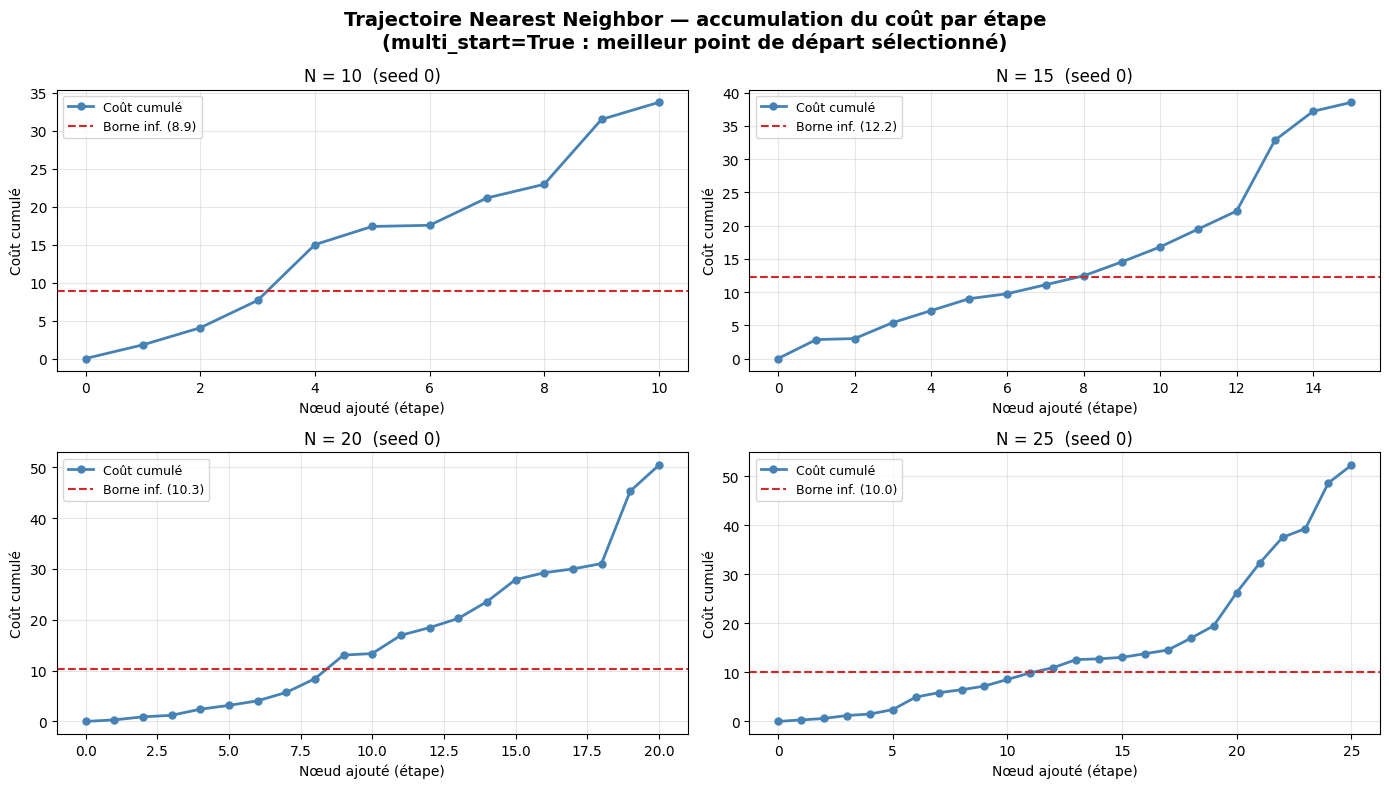

In [139]:
TRAJ_N_DISPLAY: list[int] = [10, 15, 20, 25]  # sous-ensemble de N_VALUES
TRAJ_SEED: int = 0

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, n in zip(axes, TRAJ_N_DISPLAY):
    seed, graph, ref = next(
        (s, g, r) for s, g, r in instances[n] if s == TRAJ_SEED
    )

    # multi_start=True : on cherche le meilleur point de départ
    best_history: list[float] = []
    best_cost_traj: float = float("inf")

    for start in graph.nodes():
        _, cost, history = _nearest_neighbor_tour_tracked(graph, start)
        if cost < best_cost_traj:
            best_cost_traj = cost
            best_history = history

    steps: list[int] = list(range(len(best_history)))
    labels: list[str] = ["Dépôt"] + [f"Étape {i}" for i in range(1, len(steps))]

    ax.plot(
        steps, best_history,
        marker="o", markersize=5, linewidth=2,
        color="steelblue", label="Coût cumulé"
    )
    ax.axhline(
        y=ref, color="#d62728", linestyle="--", linewidth=1.5,
        label=f"Borne inf. ({ref:.1f})"
    )
    ax.set_title(f"N = {n}  (seed {TRAJ_SEED})", fontsize=12)
    ax.set_xlabel("Nœud ajouté (étape)", fontsize=10)
    ax.set_ylabel("Coût cumulé", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    "Trajectoire Nearest Neighbor — accumulation du coût par étape\n"
    "(multi_start=True : meilleur point de départ sélectionné)",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.show()

##### 7.4.1.2. Étude de l'influence des paramètres

Le paramètre principal de l'algorithme Nearest Neighbor est **`multi_start`** (booléen) :
- `False` : une seule exécution depuis un sommet aléatoire sans précédence (résultat potentiellement très variable selon la seed)
- `True`  : une exécution depuis **chaque sommet**, la meilleure tournée est conservée (déterministe à graphe fixé)

La **heatmap à double entrée** (style GitHub) ci-dessous présente :
- En **lignes** : les tailles de graphe $N \in \{10, 12, 15, 17, 20, 22, 25, 30\}$
- En **colonnes** : les valeurs de `multi_start` testées (`False` / `True`)
- La **couleur** code le gap moyen (%) — *plus clair = meilleur résultat (gap plus faible)*

In [140]:
NB_REPEAT: int = 5  # répétitions en mode mono-start (multi_start=False) pour lisser l'aléa
MULTI_START_VALUES: list[bool] = [False, True]

gap_matrix: dict = {}
cost_results: dict = {}
gap_results: dict = {}

nb_total: int = len(N_VALUES) * len(MULTI_START_VALUES) * NB_SEEDS
print(
    f"Calcul en cours : {len(N_VALUES)} tailles × {len(MULTI_START_VALUES)} valeurs "
    f"× {NB_SEEDS} seeds = {nb_total} exécutions\n"
)

for n in N_VALUES:
    gap_matrix[n] = {}
    cost_results[n] = {}
    gap_results[n] = {}

    for ms in MULTI_START_VALUES:
        costs: list[float] = []
        gaps: list[float] = []

        for seed, graph, ref in instances[n]:
            if ms:
                # Déterministe à graphe fixé : une seule exécution suffit
                _, cost = resolve_by_nearest_neighbor(graph, multi_start=True)
                if cost < PENALTY_COST:
                    costs.append(cost)
                    gaps.append(compute_gap(cost, ref))
            else:
                # Aléatoire : on répète NB_REPEAT fois et on conserve le meilleur
                repeat_costs: list[float] = []
                for _ in range(NB_REPEAT):
                    _, cost = resolve_by_nearest_neighbor(graph, multi_start=False)
                    if cost < PENALTY_COST:
                        repeat_costs.append(cost)
                if repeat_costs:
                    best_repeat: float = min(repeat_costs)
                    costs.append(best_repeat)
                    gaps.append(compute_gap(best_repeat, ref))

        cost_results[n][ms] = costs
        gap_results[n][ms] = gaps
        gap_matrix[n][ms] = float(np.nanmean(gaps)) if gaps else float("nan")

    ms_summary = {ms: f"{gap_matrix[n][ms]:.1f}" for ms in MULTI_START_VALUES}
    print(f"  N={n:2d} : {ms_summary}")

Calcul en cours : 8 tailles × 2 valeurs × 5 seeds = 80 exécutions

  N=10 : {False: '346.1', True: '288.9'}
  N=12 : {False: '352.6', True: '341.3'}
  N=15 : {False: '371.7', True: '363.1'}
  N=17 : {False: '458.7', True: '419.3'}
  N=20 : {False: '395.5', True: '375.8'}
  N=22 : {False: '486.3', True: '434.5'}
  N=25 : {False: '522.3', True: '421.4'}
  N=30 : {False: '429.7', True: '392.3'}


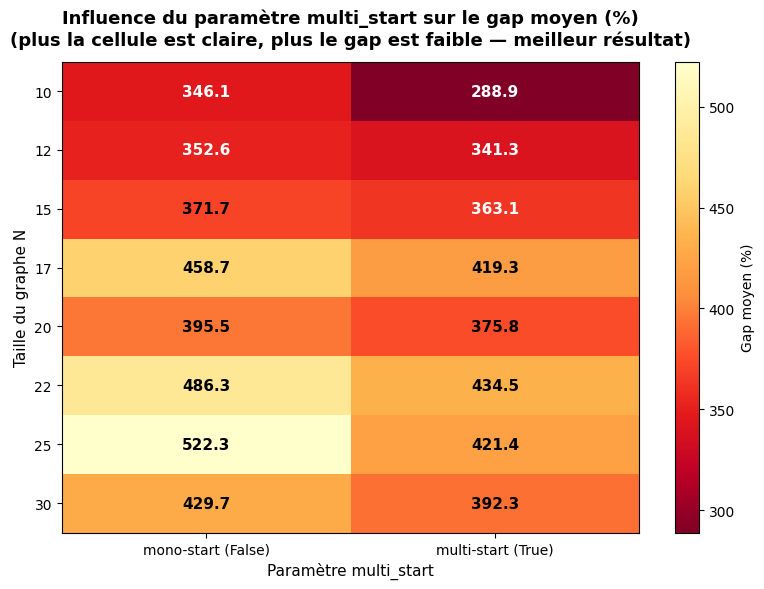

In [141]:
col_labels: dict[bool, str] = {False: "mono-start (False)", True: "multi-start (True)"}
col_order: list[bool] = [False, True]

data = np.array([[gap_matrix[n][ms] for ms in col_order] for n in N_VALUES])

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(data, cmap="YlOrRd_r", aspect="auto")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Gap moyen (%)", fontsize=10)

for i, n in enumerate(N_VALUES):
    for j, ms in enumerate(col_order):
        val = gap_matrix[n][ms]
        norm_val = (val - data.min()) / (data.max() - data.min())
        text_color = "white" if norm_val < 0.35 else "black"
        ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                fontsize=11, color=text_color, fontweight="bold")

ax.set_xticks(range(len(col_order)))
ax.set_xticklabels([col_labels[ms] for ms in col_order], fontsize=10)
ax.set_yticks(range(len(N_VALUES)))
ax.set_yticklabels(N_VALUES, fontsize=10)

ax.set_title(
    "Influence du paramètre multi_start sur le gap moyen (%)\n"
    "(plus la cellule est claire, plus le gap est faible — meilleur résultat)",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xlabel("Paramètre multi_start", fontsize=11)
ax.set_ylabel("Taille du graphe N", fontsize=11)
plt.tight_layout()
plt.show()

##### 7.4.1.3. Comparaison Multi-start vs Mono-instance

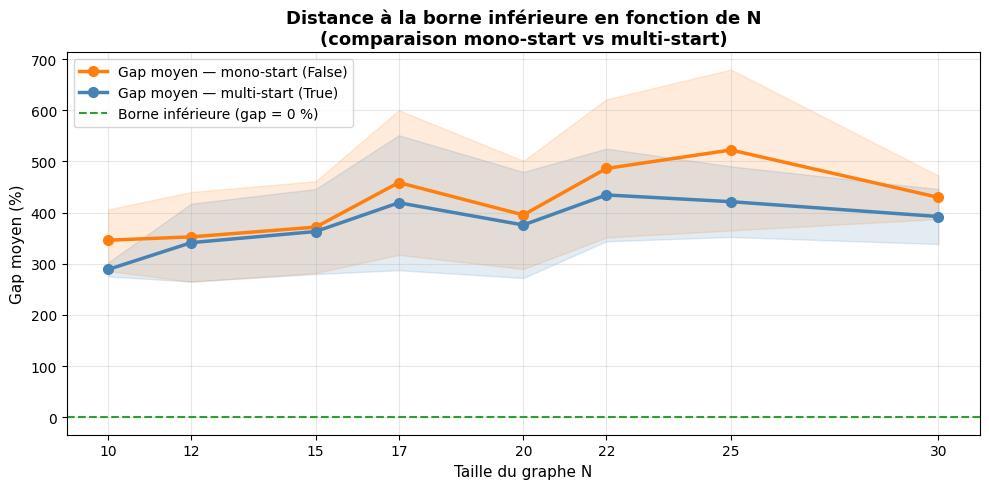

In [142]:
colors: dict[bool, str] = {True: "steelblue", False: "#ff7f0e"}
labels_ms: dict[bool, str] = {True: "multi-start (True)", False: "mono-start (False)"}

fig, ax = plt.subplots(figsize=(10, 5))

for ms in MULTI_START_VALUES:
    gap_means_arr = np.array([
        float(np.mean(gap_results[n][ms])) if gap_results[n][ms] else float("nan")
        for n in N_VALUES
    ])
    gap_stds_arr = np.array([
        float(np.std(gap_results[n][ms])) if gap_results[n][ms] else float("nan")
        for n in N_VALUES
    ])

    ax.plot(
        N_VALUES, gap_means_arr,
        "o-", linewidth=2.5, markersize=7,
        color=colors[ms], label=f"Gap moyen — {labels_ms[ms]}"
    )
    ax.fill_between(
        N_VALUES,
        np.clip(gap_means_arr - gap_stds_arr, 0, None),
        gap_means_arr + gap_stds_arr,
        alpha=0.15, color=colors[ms]
    )

ax.axhline(
    y=0, color="#2ca02c", linestyle="--", linewidth=1.5,
    label="Borne inférieure (gap = 0 %)"
)

ax.set_title(
    "Distance à la borne inférieure en fonction de N\n"
    "(comparaison mono-start vs multi-start)",
    fontsize=13, fontweight="bold",
)
ax.set_xlabel("Taille du graphe N", fontsize=11)
ax.set_ylabel("Gap moyen (%)", fontsize=11)
ax.set_xticks(N_VALUES)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### 7.4.1.4. Définition des paramètres optimisés

In [143]:
global_gap_by_ms: dict[bool, float] = {}
for ms in MULTI_START_VALUES:
    all_gaps: list[float] = []
    for n in N_VALUES:
        all_gaps.extend(gap_results[n][ms])
    global_gap_by_ms[ms] = float(np.nanmean(all_gaps)) if all_gaps else float("nan")

best_ms: bool = min(global_gap_by_ms, key=lambda k: global_gap_by_ms[k])
best_gap: float = global_gap_by_ms[best_ms]

print("=" * 62)
print("  RÉSULTATS — Nearest Neighbor")
print("=" * 62)
print(f"\n  Gap moyen global par configuration :\n")
for ms in MULTI_START_VALUES:
    arrow = "  ◄ OPTIMAL" if ms == best_ms else ""
    print(f"    multi_start = {str(ms):5s}  →  gap moyen = {global_gap_by_ms[ms]:6.2f} %{arrow}")

print(f"\n  {'─' * 48}")
print(f"  Meilleur paramètre : multi_start = {best_ms}")
print(f"  Gap moyen obtenu   : {best_gap:.2f} %")
print("=" * 62)

  RÉSULTATS — Nearest Neighbor

  Gap moyen global par configuration :

    multi_start = False  →  gap moyen = 420.35 %
    multi_start = True   →  gap moyen = 379.57 %  ◄ OPTIMAL

  ────────────────────────────────────────────────
  Meilleur paramètre : multi_start = True
  Gap moyen obtenu   : 379.57 %


### 7.4.2. Hill Climbing Multi-start

## 8.0. Conclusion

Ce livrable avait pour objectif de poser les fondements formels du problème de tournée de livraison confié par l'ADEME à CesiCDP. À travers les différentes sections, nous avons progressivement construit un cadre rigoureux, du contexte applicatif jusqu'à l'analyse de complexité.

Nous avons d'abord modélisé le problème sous la forme d'un graphe complet $G = (V, E)$, où les sommets représentent les six villes à livrer et les arêtes portent un poids reflétant le coût réel de chaque trajet, péages et consommation de carburant inclus. Deux contraintes ont été intégrées au modèle : l'interdiction de certaines routes ($P(u,v) = -1$) et des contraintes de précédence imposant un ordre de visite entre certaines villes.

Nous avons ensuite montré que ce problème, que nous notons TSP-PC-ER, est une extension du problème du Voyageur de Commerce classique. Par réduction polynomiale depuis le cycle hamiltonien, nous avons établi la chaîne :

$$\text{Ham-Cycle} \leq_p \text{TSP} \leq_p \text{TSP-PC-ER}$$

Ce résultat implique que TSP-PC-ER est NP-Difficile : aucun algorithme polynomial connu ne peut le résoudre de manière exacte pour de grandes instances. Le nombre de tournées à explorer croît de façon factorielle avec le nombre de villes, ce que le tableau de la section *4.4* illustre clairement.

Ces conclusions justifient pleinement le recours à des heuristiques dans les phases suivantes du projet, qui viseront à produire des solutions de bonne qualité en temps raisonnable, sans prétendre à l'optimalité garantie.

---


## 9.0. Références bibliographiques

### 9.1. Livres

- APPLEGATE, David L., BIXBY, Robert E., CHVÁTAL, Václav, COOK, William J. The Traveling Salesman Problem: A Computational Study. Princeton : Princeton University Press, 2006. p.606
  *Utilisé pour justifier le recours aux heuristiques face à la croissance factorielle du nombre de tournées (section 4.4).*

- GAREY, Michael R., JOHNSON, David S. Computers and Intractability: A Guide to the Theory of NP-Completeness. New York : W.H. Freeman, 1979. p.338
  *Utilisé pour appuyer la conclusion de la réduction TSP ≤p TSP-PC-ER et la NP-difficulté du problème (section 4.3).*

- FOURNIER, Jean-Claude. Théorie des graphes et applications : avec exercices et problèmes. 2e éd. revue et augmentée. Paris : Hermès - Lavoisier, 2011.
  *Utilisé pour fonder la modélisation du problème sous forme de graphe complet pondéré $G = (V, E)$ (section 2.0).*

- FAURE, Robert, LEMAIRE, Bernard, PICOULEAU, Christophe. Précis de recherche opérationnelle : Méthodes et exercices d'application. 7e éd. Paris : Dunod, 2014.
  *Utilisé pour la formulation en programmation linéaire en nombres entiers (PLNE), variables binaires $x_{u,v}$ et fonction objectif (section 2.0).*

### 9.2. Chapitres d'ouvrages collectifs

- COOK, Stephen A. The complexity of theorem-proving procedures. In Proceedings of the Third Annual ACM Symposium on Theory of Computing (STOC). New York : ACM, 1971. p. 151-158.
  *Utilisé pour fonder la notion de certificat vérifiable en temps polynomial et justifier que TSP-PC-ER ∈ NP (section 4.2).*

- GENDREAU, Michel, LAPORTE, Gilbert, POTVIN, Jean-Yves. Metaheuristics for the capacitated VRP. In TOTH, Paolo, VIGO, Daniele dir. The Vehicle Routing Problem. Philadelphia : SIAM, 2002. p. 129-154.
  *Utilisé pour justifier le recours aux heuristiques sur les extensions du TSP avec contraintes de précédence et d'arêtes bloquées (section 4.4).*

- KARP, Richard M. Reducibility among combinatorial problems. In MILLER, Raymond E., THATCHER, James W. dir. Complexity of Computer Computations. New York : Plenum Press, 1972. p. 85-103.
  *Utilisé pour établir la chaîne de réduction Ham-Cycle ≤p TSP ≤p TSP-PC-ER et la NP-difficulté du TSP (section 4.1).*

### 9.3. Articles de revues

- DANTZIG, George B., FULKERSON, D. Ray, JOHNSON, Selmer M. Solution of a large-scale traveling-salesman problem. Journal of the Operations Research Society of America, 1954, vol. 2, n° 4, p. 393-410.
  *Utilisé pour la formulation originale de la fonction objectif min Z du TSP sous forme de somme pondérée des arêtes sélectionnées (section 3.1).*